# K-Nearest Neighbor (KNN)
KNN is a simple yet powerful supervised learning algorithm used for both classification and regression tasks. It operates on the principle of finding the 'k' closest data points (neighbors) to a given input and making predictions based on their labels. This model is non-parametric, meaning it does not make any assumptions about the underlying data distribution. Works on instance based meaning it does not learn a pattern but memorizes training data, so there is no training phase. This is why it is called a lazy learner(slow for large datasets).

## Core Concepts
### KNN for Classification
1. Find K Nearest Neighbors: For a given input, the algorithm calculates the distance (commonly using Euclidean distance) to all other data points in the training set and identifies the 'k' closest ones.
2. Count Class Votes: The algorithm counts the number of occurrences of each class label among the 'k' nearest neighbors.
3. Assign Majority Class: The input data point is classified based on the majority class among its 'k' nearest neighbors.

### KNN for Regression
1. Find K Nearest Neighbors: Similar to classification, the algorithm identifies the 'k' closest data points to the input.
2. Calculate Average Value: Instead of counting class votes, the algorithm computes the average (or weighted average) of the target values of the 'k' nearest neighbors.
3. Assign Predicted Value: The input data point is assigned the calculated average value as its prediction.

### Why KNN is called a Lazy Learner?
- Traning Phase
    - No model building
    - No parameter optimization
    - Just store the dataset
    - Zero computation
- Testing Phase
    - Calculates all distances
    - Sorts neighbors
    - Aggregates results
    - All the work is done here

## KNN Behavior Control
#### Distance Metric
The choice of distance metric (e.g., Euclidean, Manhattan, Minkowski) can significantly impact the performance of the KNN algorithm.
1. Euclidean Distance: Suitable for continuous variables and works well in low-dimensional spaces.

    ```math
    d(x, z) = \sqrt{\sum_{i=1}^{n} (x_i - z_i)^2}
    ```
    Where, $x$ and $z$ are two points in n-dimensional space.

2. Manhattan Distance: More robust to outliers and works well in high-dimensional spaces.

    ```math
    d(x, z) = \sum_{i=1}^{n} |x_i - z_i|
    ```
    Where, $x$ and $z$ are two points in n-dimensional space.
3. Minkowski Distance: A generalization of both Euclidean and Manhattan distances, controlled by a parameter 'p'.

    ```math
    d(x, z) = \left( \sum_{i=1}^{n} |x_i - z_i|^p \right)^{1/p}
    ```
    Where, $x$ and $z$ are two points in n-dimensional space, and $p$ is a positive integer. When $p=2$, it is equivalent to Euclidean distance, and when $p=1$, it is equivalent to Manhattan distance.
4. Cosine Similarity: Measures the cosine of the angle between two vectors, useful for text data and high-dimensional spaces.

    ```math
    d(x, z) = \cos(\theta) =\frac{x \cdot z}{||x|| \cdot ||z||} = \frac{\sum_{i=1}^{n} x_i z_i}{\sqrt{\sum_{i=1}^{n} x_i^2} \cdot \sqrt{\sum_{i=1}^{n} z_i^2}}
    ```
    Where, $x$ and $z$ are two points in n-dimensional space. if the cosine similarity is 1, the vectors are identical; if it is 0, they are orthogonal; and if it is -1, they are diametrically opposed. 
#### Value of $K$
The value of $K$ defines how many neighboring data points the algorithm considers when making a prediction. The number of neighbors $k$ is a crucial hyperparameter. A small $k$ can lead to overfitting and very sensitive to noise, while a large $k$ may smooth out important patterns in the data but can lead to underfitting.

```math
k = \sqrt{n}
```
Where, $n$ is the number of data points in the training set. This is a common heuristic for choosing $k$, but it can be adjusted based on cross-validation results. For binary classification problems, it is often recommended to choose an odd value for $k$ to avoid ties.
#### Feature Scaling
Since KNN relies on distance calculations, it is sensitive to the scale of the features. Feature scaling techniques like normalization or standardization are often applied to ensure that all features contribute equally to the distance computation.

Sparse neiborhood vs Dense neighborhood
- In sparse neighborhoods, data points are spread out, which can lead to less reliable predictions as the nearest neighbors may be far away and not representative of the local data distribution.
- In dense neighborhoods, data points are closely packed together, allowing for more accurate predictions as the nearest neighbors are likely to be more similar to the input data point.

KNN works well with small to medium-sized datasets and is easy to implement. However, it can be computationally expensive for large datasets due to the need to calculate distances to all training points during prediction. Additionally, KNN can struggle with high-dimensional data (the "curse of dimensionality") where the distance metrics may become less meaningful.

In [6]:
from sklearn.datasets import load_wine
from sklearn.discriminant_analysis import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import pandas as pd

wine = load_wine()
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

k_values = range(1,42)
settings = [
    ("Euclidean", 2, "uniform"),
    ("Manhattan", 1, "uniform"),
    ("Euclidean", 2, "distance"),
    ("Manhattan", 1, "distance"),
]   # distance metric, p value, weight type: uniform for all neighbors same weight, distance for closer neighbors higher weight

results = []

for k in k_values:
    for metric_name, p_val, weight_mode in settings:
        
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k, p=p_val, weights=weight_mode))
        ])
        
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        
        results.append({
            "k": k,
            "Metric": metric_name,
            "Weights": weight_mode,
            "Accuracy": acc
        })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by=["Accuracy", "k"], ascending=[False, True]).reset_index(drop=True)
df_results.head(10)

,k,Metric,Weights,Accuracy
0,14,Euclidean,distance,1.0
1,15,Euclidean,uniform,1.0
2,15,Euclidean,distance,1.0
3,16,Euclidean,distance,1.0
4,17,Euclidean,uniform,1.0
5,17,Euclidean,distance,1.0
6,18,Euclidean,uniform,1.0
7,18,Euclidean,distance,1.0
8,19,Euclidean,uniform,1.0
9,19,Euclidean,distance,1.0


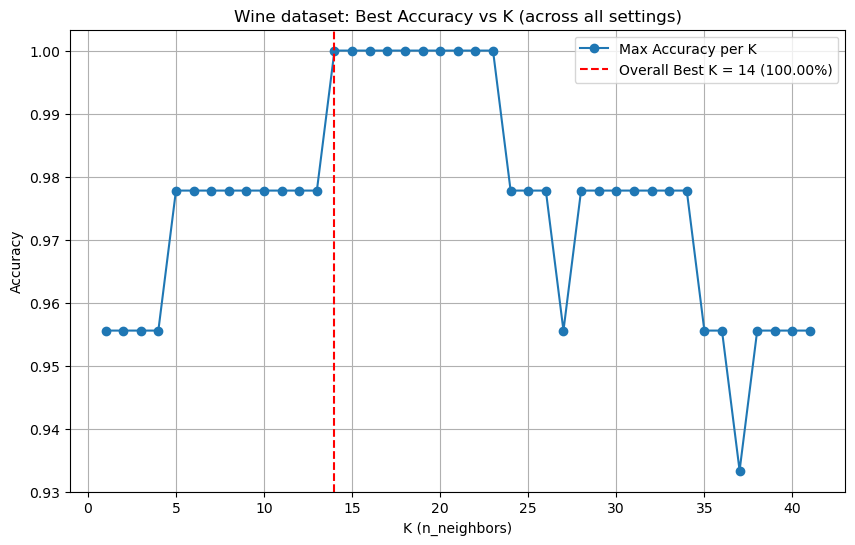

In [9]:
import matplotlib.pyplot as plt
import numpy as np

best_row_idx = df_results["Accuracy"].idxmax()
best_k = df_results.loc[best_row_idx, "k"]
best_acc = df_results.loc[best_row_idx, "Accuracy"]
max_scores_per_k = df_results.groupby("k")["Accuracy"].max()

plt.figure(figsize=(10, 6))
plt.plot(max_scores_per_k.index, max_scores_per_k.values, marker='o', label="Max Accuracy per K")
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Overall Best K = {best_k} ({best_acc:.2%})')

plt.xlabel("K (n_neighbors)")
plt.ylabel("Accuracy")
plt.title("Wine dataset: Best Accuracy vs K (across all settings)")
plt.legend()
plt.grid(True)
plt.show()